In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/UCI_Credit_Card.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (30000, 25)

Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
# Check basic info
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDefault rate:")
print(df['default.payment.next.month'].value_counts())
print("\nDefault %:", round(df['default.payment.next.month'].mean()*100, 2), "%")

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

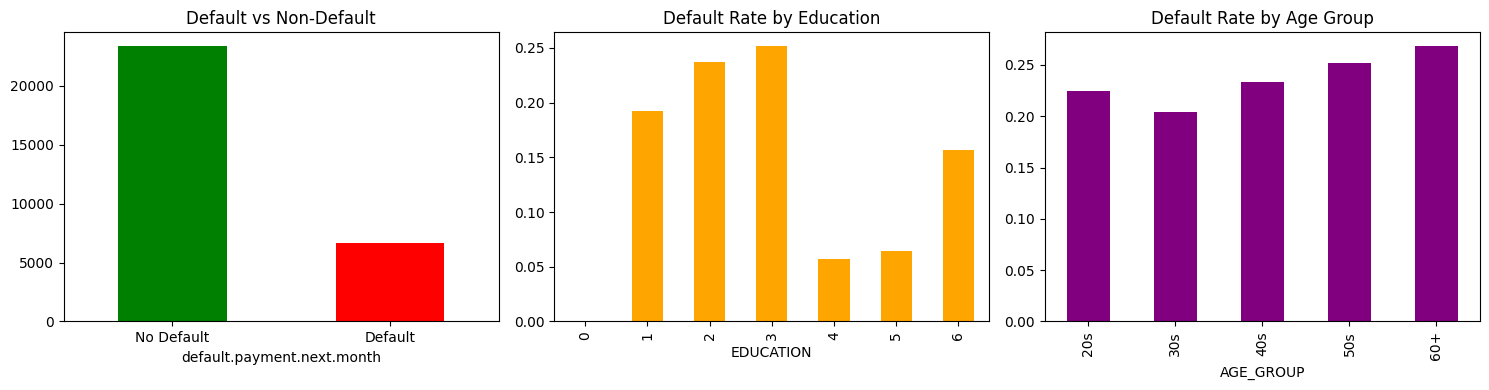

In [3]:
# Visualize default rate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Default distribution
df['default.payment.next.month'].value_counts().plot(
    kind='bar', ax=axes[0], color=['green','red'])
axes[0].set_title('Default vs Non-Default')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)

# Default by Education
df.groupby('EDUCATION')['default.payment.next.month'].mean().plot(
    kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Default Rate by Education')

# Default by Age group
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80], 
                          labels=['20s','30s','40s','50s','60+'])
df.groupby('AGE_GROUP', observed=True)['default.payment.next.month'].mean().plot(
    kind='bar', ax=axes[2], color='purple')
axes[2].set_title('Default Rate by Age Group')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop the ID column and AGE_GROUP we created
df = df.drop(['ID', 'AGE_GROUP'], axis=1)

# Rename target column for simplicity
df = df.rename(columns={'default.payment.next.month': 'default'})

# Features and target
X = df.drop('default', axis=1)
y = df['default']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Default rate in test:", round(y_test.mean()*100, 2), "%")

Training set: (24000, 23)
Test set: (6000, 23)
Default rate in test: 22.12 %


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Train XGBoost
loan_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

loan_model.fit(X_train, y_train)
print("✅ Loan Default Model trained!")

# Predict
y_pred = loan_model.predict(X_test)
y_pred_proba = loan_model.predict_proba(X_test)[:, 1]

# Results
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Default', 'Default']))
print("🎯 ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

✅ Loan Default Model trained!

📊 Classification Report:
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

🎯 ROC-AUC Score: 0.7775


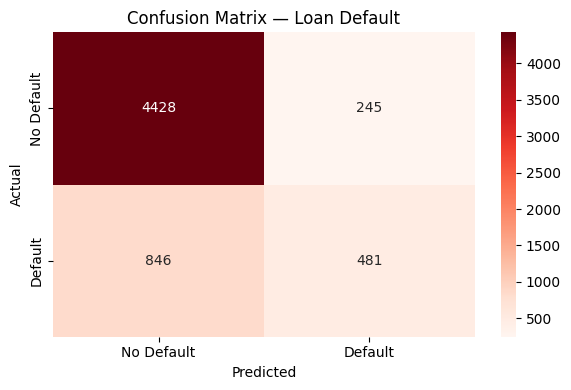


💰 Sample Customer Risk Scores:
Customer 1: 13.5% default risk → 🟢 LOW
Customer 2: 14.5% default risk → 🟢 LOW
Customer 3: 18.8% default risk → 🟢 LOW
Customer 4: 14.0% default risk → 🟢 LOW
Customer 5: 3.2% default risk → 🟢 LOW


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — Loan Default')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Show Risk Score example
sample_customer = X_test[:5]
risk_scores = loan_model.predict_proba(sample_customer)[:, 1] * 100

print("\n💰 Sample Customer Risk Scores:")
for i, score in enumerate(risk_scores):
    risk_level = "🔴 HIGH" if score > 60 else "🟡 MEDIUM" if score > 30 else "🟢 LOW"
    print(f"Customer {i+1}: {score:.1f}% default risk → {risk_level}")

In [7]:
import joblib

# Save model and scaler
joblib.dump(loan_model, 'loan_model.pkl')
joblib.dump(scaler, 'loan_scaler.pkl')
joblib.dump(X.columns.tolist(), 'loan_features.pkl')

print("✅ loan_model.pkl saved!")
print("✅ loan_scaler.pkl saved!")
print("✅ loan_features.pkl saved!")
print("\nFeatures used:", X.columns.tolist())

✅ loan_model.pkl saved!
✅ loan_scaler.pkl saved!
✅ loan_features.pkl saved!

Features used: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
